<a href="https://colab.research.google.com/github/samuelglezact-oss/Rendimiento_Academico/blob/main/01_exploracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importamos la base de datos
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Econometría_1/df_Final_corregido.xlsx')
df

,Edad,Area_Academica,Hrs de Sueño,Ingreso_Mensual,Tiempo_Traslado_Min,Transporte,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,...,Promedio,Nivel de estres,Metodo de estudio,Nivel de interes,Area de interes,Categoria_Predominante,Transp_a_pie,Transp_por_app,Transp_publico,Transp_propio
0,22,Exactas e Ingenierías,8,5,7.5,A pie,0,2,2,5,...,8.70,3,0,3,Probabilidad y estadística,Exactas y Métodos,1,0,0,0
1,21,Exactas e Ingenierías,8,2,52.5,"Transporte público (Autobús, Metro, etc.)",0,4,1,3,...,7.00,4,1,3,Matemáticas,Exactas y Métodos,0,0,1,0
2,23,Exactas e Ingenierías,8,5,30.0,Vehículo propio (Automóvil/Motocicleta),0,4,1,2,...,9.25,1,0,4,Finanzas,Exactas y Métodos,0,0,0,1
3,20,Artes y Diseño,8,2,52.5,"Transporte público (Autobús, Metro, etc.)",0,2,2,5,...,9.00,4,0,5,Comunicación,Diseño y Artes,0,0,1,0
4,21,Artes y Diseño,5,1,30.0,"Transporte público (Autobús, Metro, etc.)",0,2,1,2,...,8.34,5,0,3,Artes,Diseño y Artes,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,20,Salud y Naturales,6,2,75.0,"Transporte público (Autobús, Metro, etc.)",0,2,4,3,...,8.00,3,0,5,Salud,Salud y Biológicas,0,0,1,0
147,21,Artes y Diseño,6,3,7.5,Vehículo propio (Automóvil/Motocicleta),0,3,0,4,...,9.60,4,0,4,Diseño gráfico,Diseño y Artes,0,0,0,1
148,21,Salud y Naturales,6,5,30.0,Vehículo propio (Automóvil/Motocicleta),1,2,2,2,...,9.40,3,1,5,Salud,Salud y Biológicas,0,0,0,1
149,22,Sociales y Humanidades,7,2,52.5,"Transporte por aplicación (Uber, Didi, Taxi)",1,3,1,3,...,8.20,5,1,5,Finanzas,Económico-Administrativa,0,1,0,0


In [ ]:
#Se hace una limpieza para poder hacer estadistica descriptiva de las variables escogidas.
df_1 = df.drop(['Edad', 'Ingreso_Mensual', 'Area_Academica', 'Transporte', 'Metodo de estudio','Promedio', 'Area de interes',
         'Categoria_Predominante','Transp_a_pie','Nivel de interes', 'Transp_por_app', 'Transp_publico','Transp_propio'],axis=1)
df_1

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
0,8,7.5,0,2,2,5,4,3
1,8,52.5,0,4,1,3,5,4
2,8,30.0,0,4,1,2,6,1
3,8,52.5,0,2,2,5,4,4
4,5,30.0,0,2,1,2,9,5
...,...,...,...,...,...,...,...,...
146,6,75.0,0,2,4,3,6,3
147,6,7.5,0,3,0,4,7,4
148,6,30.0,1,2,2,2,6,3
149,7,52.5,1,3,1,3,6,5


In [ ]:
#Hacemos estadística descriptiva de cada variable, sacando la media, desviación estandar, mímino, máximo, y cuartiles de las variables explicativas.
df_1.describe()

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,6.364238,40.480132,0.258278,2.748344,2.059603,3.192053,6.145695,3.701987
std,1.098383,32.032165,0.439144,0.793461,1.255557,1.304941,1.546598,0.957738
min,3.000000,7.500000,0.000000,1.000000,0.000000,1.000000,4.000000,1.000000
25%,6.000000,7.500000,0.000000,2.000000,1.000000,2.000000,5.000000,3.000000
50%,6.000000,30.000000,0.000000,3.000000,2.000000,3.000000,6.000000,4.000000
75%,7.000000,52.500000,1.000000,3.000000,3.000000,4.000000,7.000000,4.000000
max,8.000000,135.000000,1.000000,5.000000,5.000000,5.000000,9.000000,5.000000


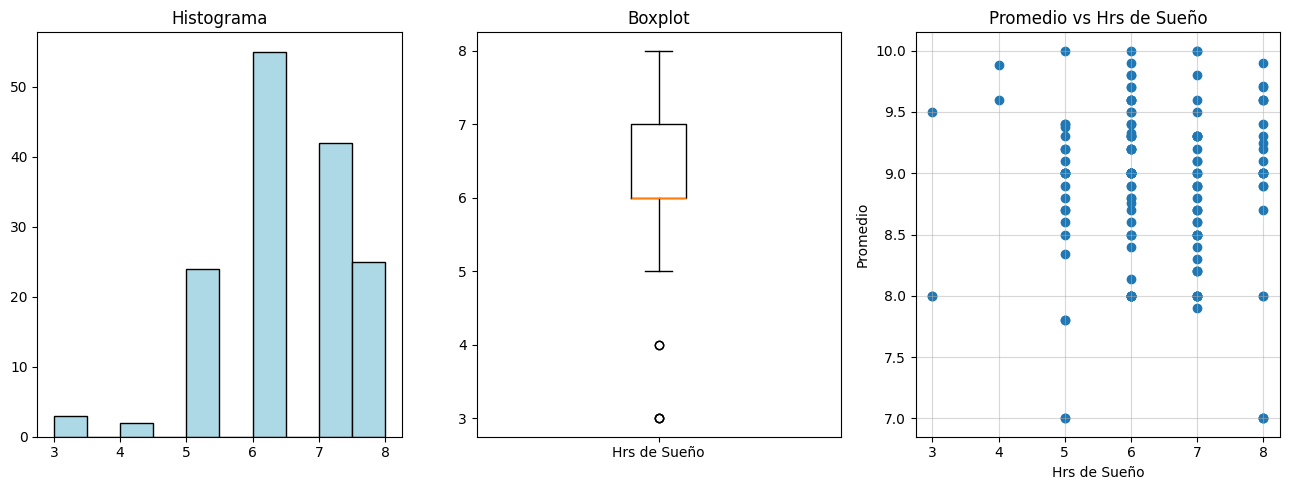

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE SUEÑO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))

ax[0].hist(df_1['Hrs de Sueño'], color='lightblue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de Sueño'].dropna(), tick_labels=['Hrs de Sueño'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de Sueño'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs de Sueño')
ax[2].set_xlabel('Hrs de Sueño')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1450/479666456.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Tiempo_Traslado_Min'].dropna(), labels=['Tiempo_Traslado_Min'])


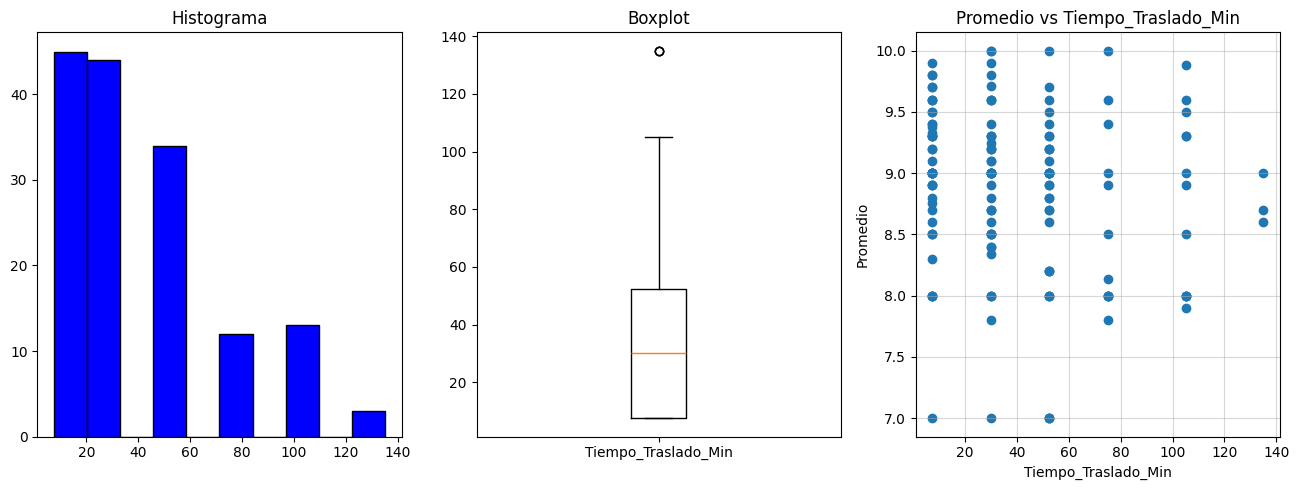

In [ ]:
#Comparamos las diferentes gráficas de la variable "TIEMPO DE TRASLADO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Tiempo_Traslado_Min'], color='blue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Tiempo_Traslado_Min'].dropna(), labels=['Tiempo_Traslado_Min'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Tiempo_Traslado_Min'], df['Promedio'])
ax[2].set_title('Promedio vs Tiempo_Traslado_Min')
ax[2].set_xlabel('Tiempo_Traslado_Min')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1450/1220959988.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Número de comidas'].dropna(), labels=['Número de comidas'])


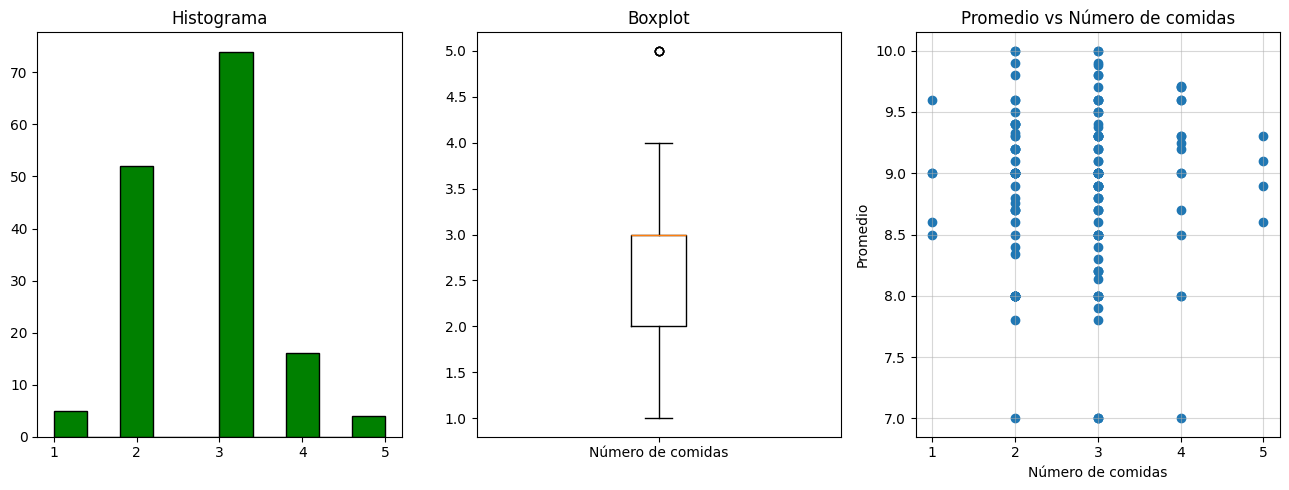

In [ ]:
#Comparamos las diferentes gráficas de la variable "NÚMERO DE COMIDAS"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Número de comidas'], color='green', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Número de comidas'].dropna(), labels=['Número de comidas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Número de comidas'], df['Promedio'])
ax[2].set_title('Promedio vs Número de comidas')
ax[2].set_xlabel('Número de comidas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1450/488672621.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Hrs de estudio'].dropna(), labels=['Hrs de estudio'])


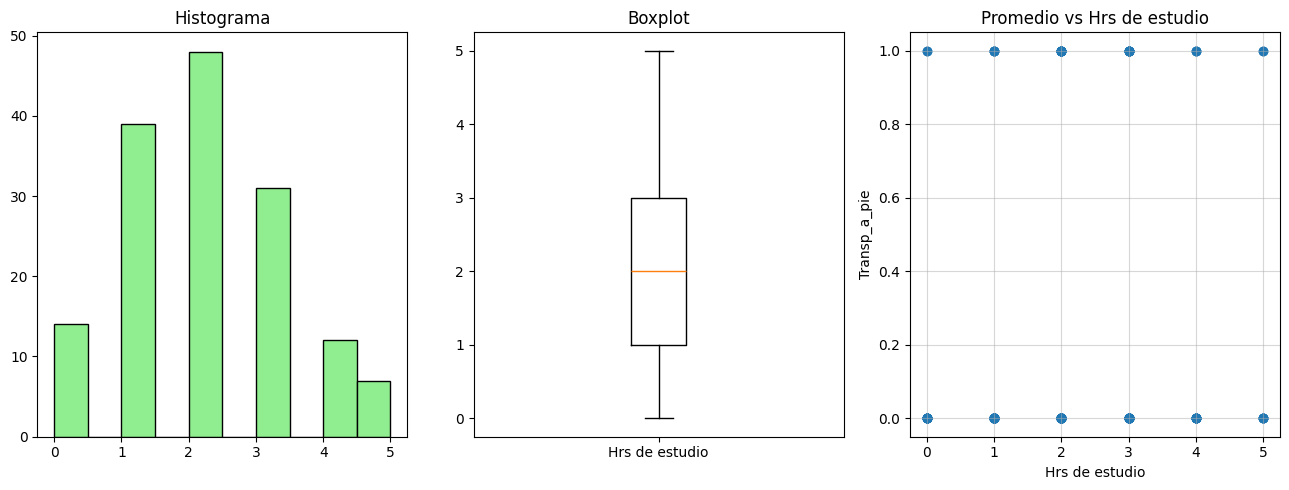

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE ESTUDIO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs de estudio'], color='lightgreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de estudio'].dropna(), labels=['Hrs de estudio'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de estudio'], df['Transp_a_pie'])
ax[2].set_title('Promedio vs Hrs de estudio')
ax[2].set_xlabel('Hrs de estudio')
ax[2].set_ylabel('Transp_a_pie')


plt.tight_layout()
plt.show()

/tmp/ipykernel_1450/3214550069.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Hrs en Redes'].dropna(), labels=['Hrs en Redes'])


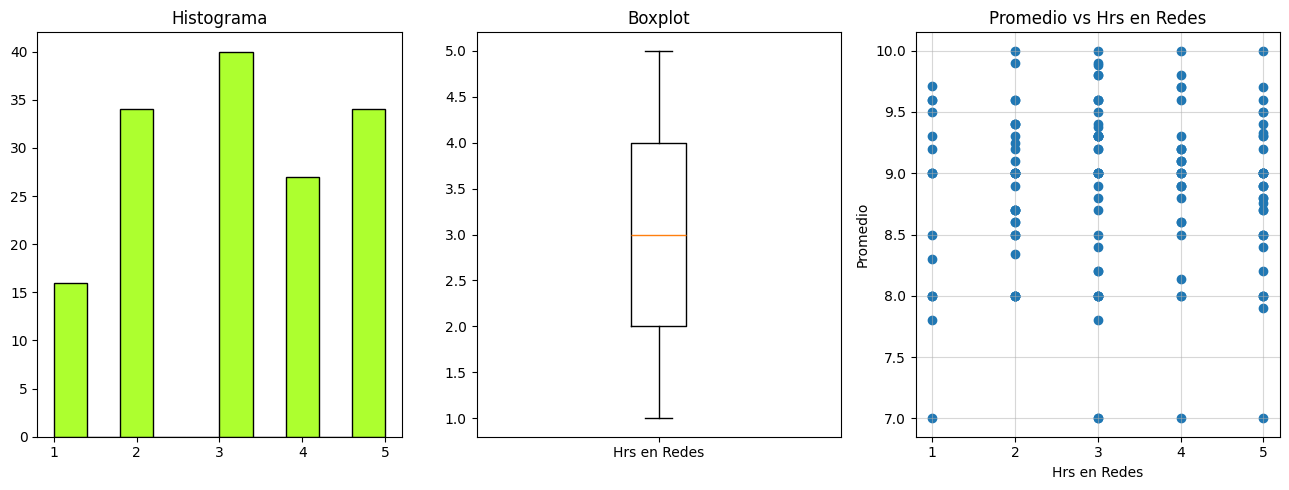

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS EN REDES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs en Redes'], color='greenyellow', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs en Redes'].dropna(), labels=['Hrs en Redes'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs en Redes'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs en Redes')
ax[2].set_xlabel('Hrs en Redes')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

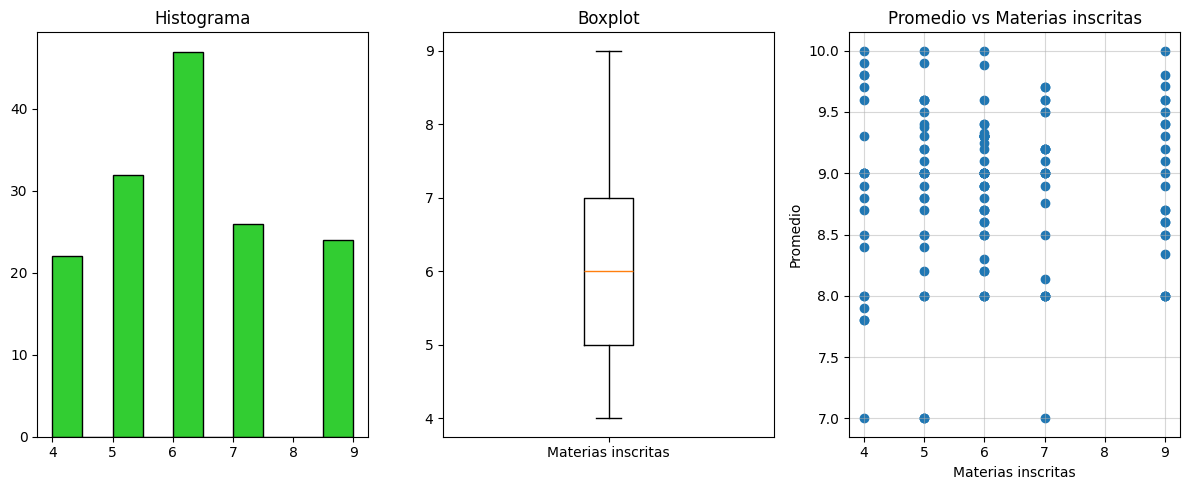

In [ ]:
#Comparamos las diferentes gráficas de la variable "MATERIAS INSCRITAS"
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].hist(df_1['Materias inscritas'], color='limegreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Materias inscritas'].dropna(), tick_labels=['Materias inscritas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Materias inscritas'], df['Promedio'])
ax[2].set_title('Promedio vs Materias inscritas')
ax[2].set_xlabel('Materias inscritas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1450/61035835.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(df_1['Nivel de estres'].dropna(), labels=['Nivel de estres'])


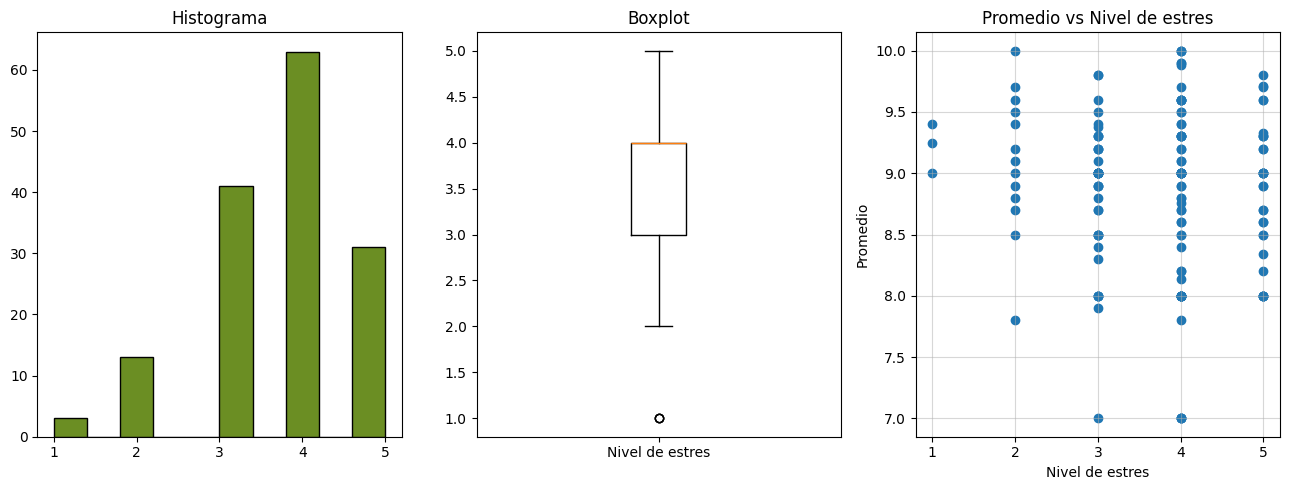

In [ ]:
#Comparamos las diferentes gráficas de la variable "NIVEL DE ESTRES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Nivel de estres'], color='olivedrab', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Nivel de estres'].dropna(), labels=['Nivel de estres'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Nivel de estres'], df['Promedio'])
ax[2].set_title('Promedio vs Nivel de estres')
ax[2].set_xlabel('Nivel de estres')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Vemos posible correlación entre variables explicativas
df_1.corr()

,Hrs de Sueño,Tiempo_Traslado_Min,Trabajo,Número de comidas,Hrs de estudio,Hrs en Redes,Materias inscritas,Nivel de estres
Hrs de Sueño,1.000000,-0.122009,-0.127229,0.190020,-0.156037,-0.025874,-0.200198,-0.206656
Tiempo_Traslado_Min,-0.122009,1.000000,-0.062192,0.072983,-0.005689,-0.004214,0.038613,0.154638
Trabajo,-0.127229,-0.062192,1.000000,-0.118344,-0.076470,-0.191837,0.081646,0.057420
Número de comidas,0.190020,0.072983,-0.118344,1.000000,0.001773,-0.017397,-0.160063,-0.090574
Hrs de estudio,-0.156037,-0.005689,-0.076470,0.001773,1.000000,-0.076205,0.074461,0.164558
Hrs en Redes,-0.025874,-0.004214,-0.191837,-0.017397,-0.076205,1.000000,-0.109751,-0.092589
Materias inscritas,-0.200198,0.038613,0.081646,-0.160063,0.074461,-0.109751,1.000000,0.227541
Nivel de estres,-0.206656,0.154638,0.057420,-0.090574,0.164558,-0.092589,0.227541,1.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
#Calculamos el VIF de cada variable para ver multicolinealidad
x = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,114.942718
1,Hrs de Sueño,1.156309
2,Trabajo,1.090833
3,Hrs de estudio,1.069467
4,Hrs en Redes,1.070453
5,Nivel de estres,1.135295
6,Materias inscritas,1.110913
7,Tiempo_Traslado_Min,1.054850
8,Número de comidas,1.078337


In [ ]:
#Verificamos si existen outliers en nuestros datos
vars_modelo = ['Promedio','Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes',
               'Nivel de estres','Materias inscritas','Tiempo_Traslado_Min',
               'Número de comidas']
def detectar_outliers_iqr(data, columnas):
    resumen = []
    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        resumen.append([col, lower, upper, n_outliers])
    return pd.DataFrame(resumen, columns=['Variable','Límite inferior','Límite superior','N_outliers'])

outliers = detectar_outliers_iqr(df, vars_modelo)
outliers

,Variable,Límite inferior,Límite superior,N_outliers
0,Promedio,7.3,10.5,5
1,Hrs de Sueño,4.5,8.5,5
2,Trabajo,-1.5,2.5,0
3,Hrs de estudio,-2.0,6.0,0
4,Hrs en Redes,-1.0,7.0,0
5,Nivel de estres,1.5,5.5,3
6,Materias inscritas,2.0,10.0,0
7,Tiempo_Traslado_Min,-60.0,120.0,3
8,Número de comidas,0.5,4.5,4


In [ ]:
# Generamos el primer modelo, tomando 8 variables de nuestra base de datos.
y = df['Promedio']
X = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.328
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.234
Time:                        04:40:26   Log-Likelihood:                -144.72
No. Observations:                 151   AIC:                             307.4
Df Residuals:                     142   BIC:                             334.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   8.6407      0.568     15.222      0.000       7.519       9.763
Hrs de Sueño           -0.0095      0.052     -0.183      0.855      -0.112       0.093
Trabajo                 0.0718      0.126      0.568      0.571      -0.178       0.322
Hrs de estudio          0.0867      0.044      1.982      0.049       0.000       0.173
Hrs en Redes            0.0260      0.042      0.617      0.538      -0.057       0.109
Nivel de estres        -0.0690      0.059     -1.167      0.245      -0.186       0.048
Materias inscritas      0.0356      0.036      0.983      0.327      -0.036       0.107
Tiempo_Traslado_Min    -0.0031      0.002     -1.825      0.070      -0.006       0.000
Número de comidas       0.0622      0.070      0.895      0.373      -0.075       0.200
==============================================================================
Omnibus:                        9.830   Durbin-Watson:                   1.902
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                9.981
Skew:                          -0.546   Prob(JB):                      0.00680
Kurtosis:                       3.627   Cond. No.                         563.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Prueba Breusch–Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(8.80298327523867), 'LM p-value': np.float64(0.3591878338719044), 'F Statistic': np.float64(1.0988483213957438), 'F p-value': np.float64(0.3675530238815836)}


In [ ]:
#Prueba Ramsey RESET
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model, power=2, use_f=True)
print(reset_test)

<F test: F=0.0639207242491457, p=0.8007712924662959, df_denom=141, df_num=1>


In [ ]:
y = df['Promedio']
X = df[['Hrs de Sueño','Hrs de estudio','Número de comidas']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.280
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.283
Time:                        04:40:26   Log-Likelihood:                -148.22
No. Observations:                 151   AIC:                             304.4
Df Residuals:                     147   BIC:                             316.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.5855      0.365     23.535      0.000       7.865       9.306
Hrs de Sueño          0.0010      0.050      0.021      0.983      -0.098       0.100
Hrs de estudio        0.0793      0.043      1.839      0.068      -0.006       0.164
Número de comidas     0.0413      0.069      0.601      0.549      -0.094       0.177
==============================================================================
Omnibus:                       11.558   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               11.898
Skew:                          -0.647   Prob(JB):                      0.00261
Kurtosis:                       3.467   Cond. No.                         51.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y = df['Promedio']
X = df[['Nivel de estres','Tiempo_Traslado_Min','Hrs en Redes','Trabajo']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.156
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.333
Time:                        04:40:26   Log-Likelihood:                -147.81
No. Observations:                 151   AIC:                             305.6
Df Residuals:                     146   BIC:                             320.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.0851      0.268     33.842      0.000       8.555       9.616
Nivel de estres        -0.0405      0.057     -0.713      0.477      -0.153       0.072
Tiempo_Traslado_Min    -0.0031      0.002     -1.810      0.072      -0.006       0.000
Hrs en Redes            0.0146      0.042      0.349      0.727      -0.068       0.097
Trabajo                 0.0429      0.124      0.345      0.731      -0.203       0.289
==============================================================================
Omnibus:                       12.307   Durbin-Watson:                   1.839
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.863
Skew:                          -0.653   Prob(JB):                      0.00161
Kurtosis:                       3.580   Cond. No.                         266.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y = df['Promedio']
X = df[['Materias inscritas']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.4832
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.488
Time:                        04:40:26   Log-Likelihood:                -149.92
No. Observations:                 151   AIC:                             303.8
Df Residuals:                     149   BIC:                             309.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.7205      0